**Mount Google Drive**

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Libraries**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

**Dataset Path**

In [ ]:
DATASET_DIR = '/content/drive/MyDrive/brain_tumor_dataset'

**Image Size**

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

**Load Dataset**

In [21]:
images = []
labels = []

for folder_name in sorted(os.listdir(DATASET_DIR)):

    folder_path = os.path.join(DATASET_DIR, folder_name)

    if os.path.isdir(folder_path):
        label = folder_name

        for img_name in os.listdir(folder_path):

            img_path = os.path.join(folder_path, img_name)

            # Load and resize image
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            img_array = img_to_array(img) / 255.0

            images.append(img_array)
            labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Dataset Loaded:", images.shape[0], "images")
print("Image Shape:", images.shape[1:])

Dataset Loaded: 253 images
Image Shape: (128, 128, 3)


**Show Sample Images**

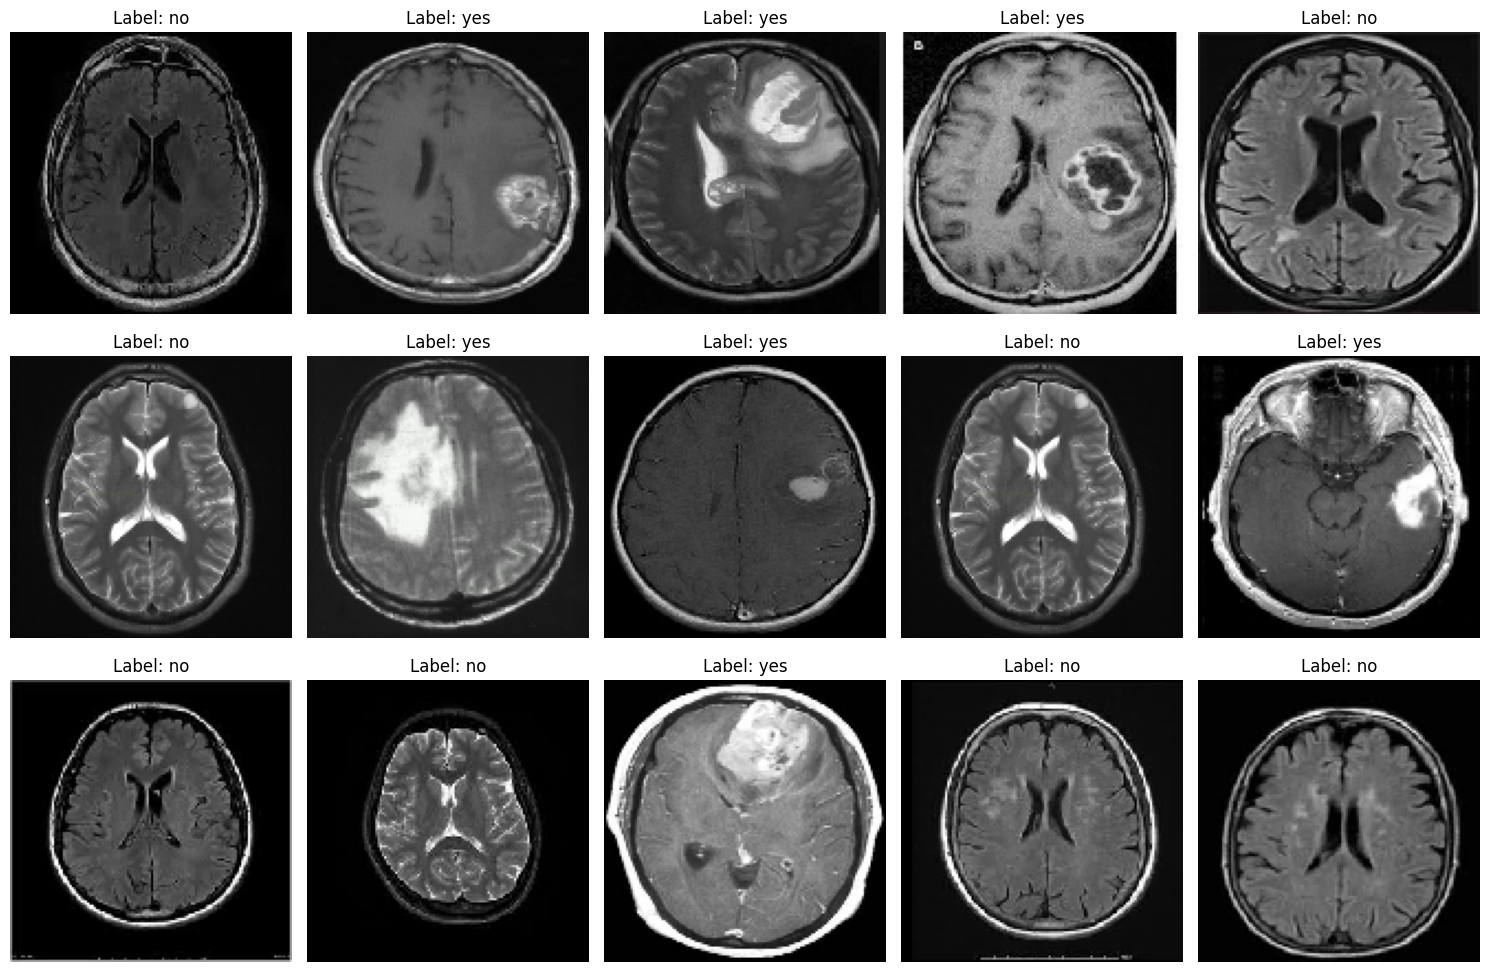

In [22]:
fig, axes = plt.subplots(3,5, figsize=(15,10))
axes = axes.ravel()

for i in range(15):

    idx = np.random.randint(0, len(images))

    axes[i].imshow(images[idx])
    axes[i].set_title(f"Label: {labels[idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Convert Labels to Numbers (Important for CNN)**

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
labels = encoder.fit_transform(labels)

print("Classes:", encoder.classes_)

Classes: ['no' 'yes']


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (202, 128, 128, 3)
Testing samples: (51, 128, 128, 3)


**Show Training Samples**

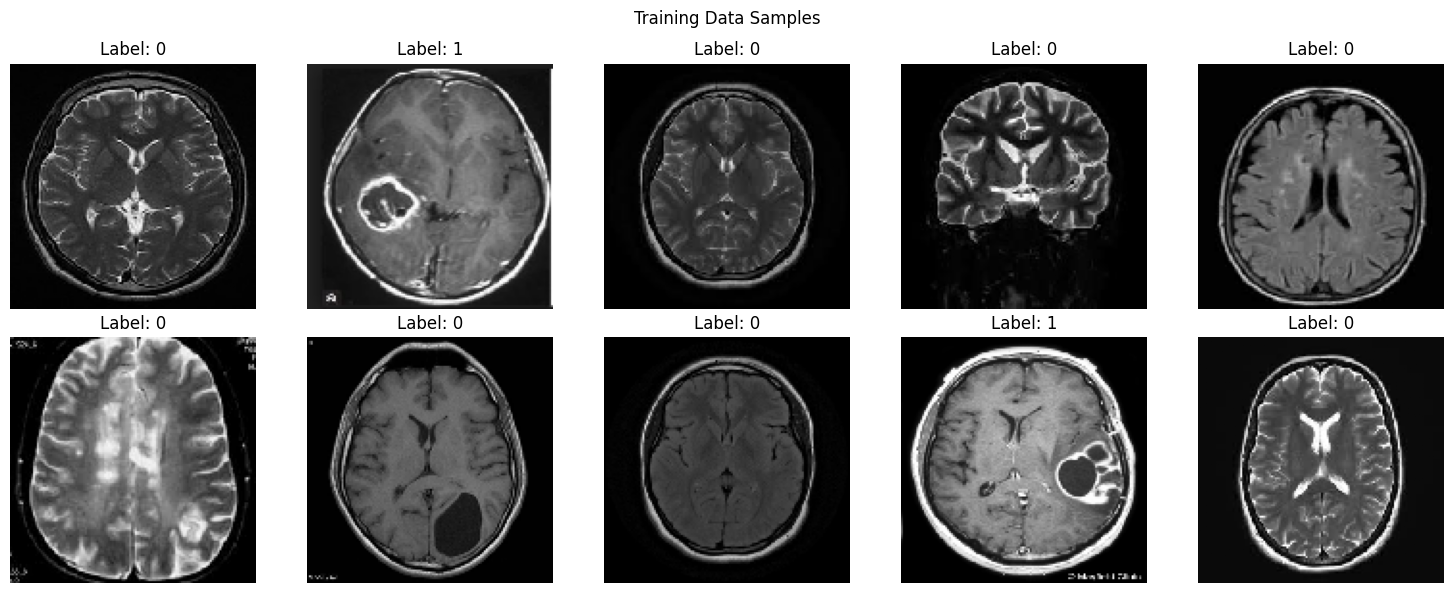

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2,5, figsize=(15,6))
axes = axes.ravel()

for i in range(10):

    idx = np.random.randint(0, len(X_train))

    axes[i].imshow(X_train[idx])
    axes[i].set_title(f"Label: {y_train[idx]}")
    axes[i].axis("off")

plt.suptitle("Training Data Samples")
plt.tight_layout()
plt.show()

**Show Testing Samples**

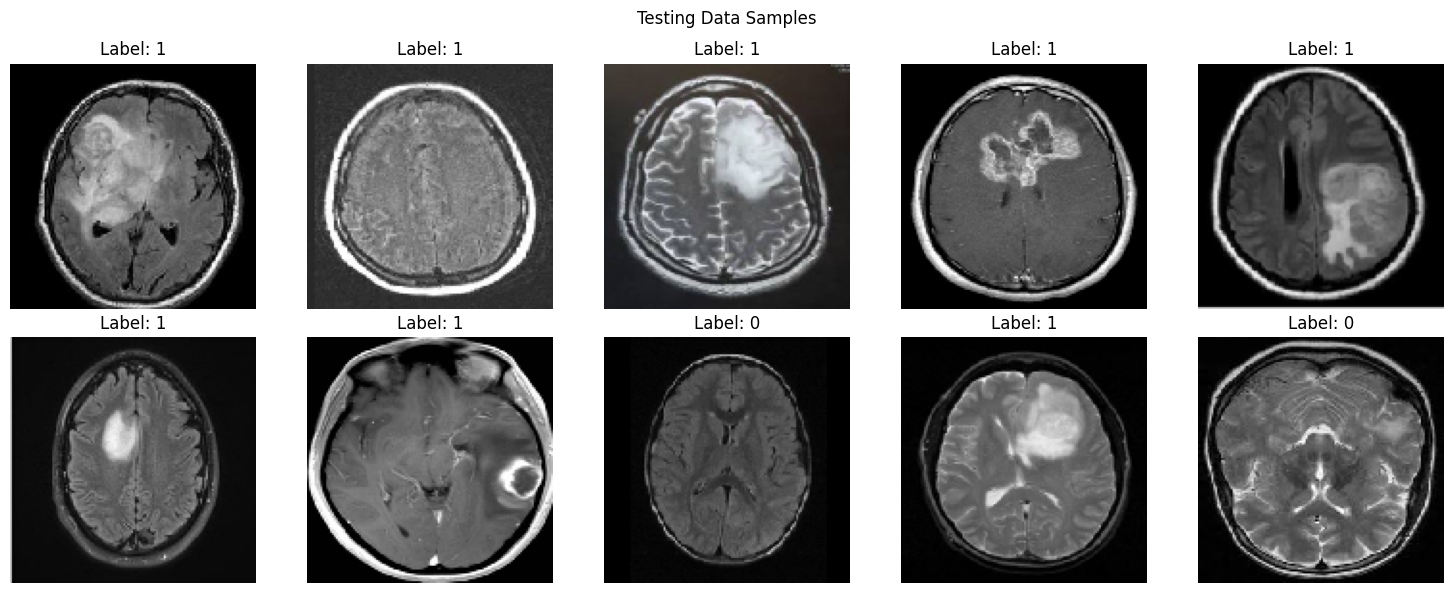

In [41]:
fig, axes = plt.subplots(2,5, figsize=(15,6))
axes = axes.ravel()

for i in range(10):

    idx = np.random.randint(0, len(X_test))

    axes[i].imshow(X_test[idx])
    axes[i].set_title(f"Label: {y_test[idx]}")
    axes[i].axis("off")

plt.suptitle("Testing Data Samples")
plt.tight_layout()
plt.show()

**Data Augmentation**

In [26]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# datagen = ImageDataGenerator(
#     rotation_range=20,
#     zoom_range=0.15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     horizontal_flip=True
# )

# datagen.fit(X_train)

**Build CNN Model**

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [47]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Early Stopping**

In [38]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

**Train the CNN**

In [48]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6337 - loss: 0.7801 - val_accuracy: 0.7843 - val_loss: 0.6227
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7772 - loss: 0.5581 - val_accuracy: 0.6863 - val_loss: 0.5924
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7970 - loss: 0.4872 - val_accuracy: 0.7451 - val_loss: 0.6098
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8069 - loss: 0.4499 - val_accuracy: 0.7647 - val_loss: 0.5916
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 950ms/step - accuracy: 0.8119 - loss: 0.4744 - val_accuracy: 0.7255 - val_loss: 0.6086
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8317 - loss: 0.4592 - val_accuracy: 0.7843 - val_loss: 0.5992
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 984ms/step - accuracy: 0.8317 - loss: 0.3663 - val_accuracy: 0.7255 - val_loss: 0.6062
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8762 - loss: 0.3279 - val_accuracy: 0.7451 - val_loss: 0.6592
Epoch 9/

**Evaluate Model**

In [49]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.7647 - loss: 1.0354
Test Accuracy: 0.7647058963775635


**As in CNN the accuracy is 76 so  i have decided to use ResNet50 This works very well for small datasets like THIS**

**Import ResNet50**

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from google.colab import drive

**Mount Google Drive**

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


**Dataset Path**

In [6]:
DATASET_DIR = '/content/drive/MyDrive/brain_tumor_dataset'

**Image Size for ResNet**

In [7]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

**Load Images with ResNet Preprocessing**

In [8]:
images = []
labels = []

for folder_name in sorted(os.listdir(DATASET_DIR)):

    folder_path = os.path.join(DATASET_DIR, folder_name)

    if os.path.isdir(folder_path):

        label = folder_name

        for img_name in os.listdir(folder_path):

            img_path = os.path.join(folder_path, img_name)

            # Load image
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))

            # Convert image to array
            img_array = img_to_array(img)

            # ResNet preprocessing
            img_array = preprocess_input(img_array)

            images.append(img_array)
            labels.append(label)

**Convert to NumPy Arrays**

In [9]:
images = np.array(images)
labels = np.array(labels)

print("Dataset Loaded:", images.shape[0], "images")
print("Image Shape:", images.shape[1:])

Dataset Loaded: 253 images
Image Shape: (224, 224, 3)


**Encode Labels**

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
labels = encoder.fit_transform(labels)

print("Classes:", encoder.classes_)

Classes: ['no' 'yes']


**Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (202, 224, 224, 3)
Testing samples: (51, 224, 224, 3)


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

**Load Pretrained ResNet50**

In [13]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Freeze ResNet Layers**

In [14]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

**Add Custom Classification Layers**

In [15]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)


predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

**Compile the Model**

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

**Train the Model**

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 1.0000 - loss: 8.2261e-04 - val_accuracy: 0.8431 - val_loss: 0.6376
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8431 - val_loss: 0.6519
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8627 - val_loss: 0.6444
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8627 - val_loss: 0.6335
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8431 - val_loss: 0.6274
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 1.0000 - loss: 8.2687e-04 - val_accuracy: 0.8431 - val_loss: 0.5924
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8431 - val_loss: 0.5830
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 1.0000 - loss: 4.0425e-04 - val_accuracy: 0.8431

**Evaluate the Model**

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.9216 - loss: 0.8005
Test Accuracy: 0.9215686321258545


**Plot Training vs Validation Accuracy**

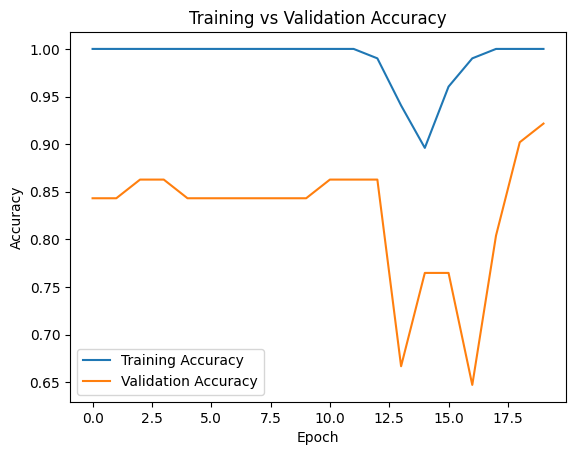

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

**Confusion Matrix**

2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step


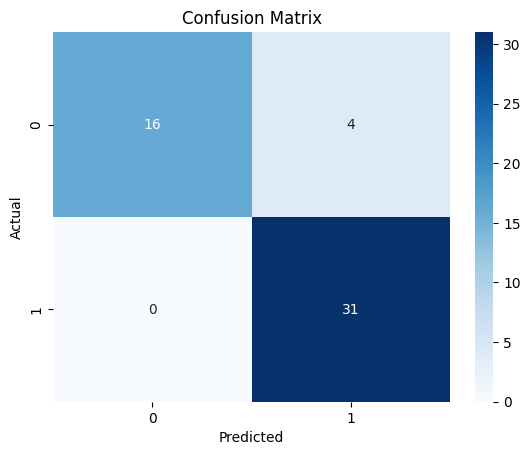

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Classification Report**

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        20
           1       0.89      1.00      0.94        31

    accuracy                           0.92        51
   macro avg       0.94      0.90      0.91        51
weighted avg       0.93      0.92      0.92        51



**Predict a Random Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


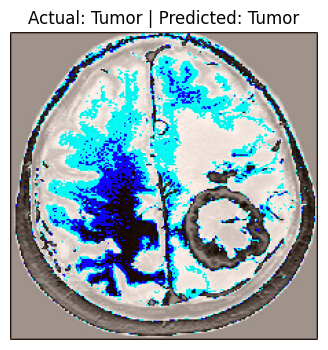

Actual Label: Tumor
Predicted Label: Tumor
Prediction Result: Correct


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Label mapping
label_map = {0: "No Tumor", 1: "Tumor"}

# Select random test image
idx = np.random.randint(0, len(X_test))

# Actual label
actual_label = y_test[idx]

# Prediction
prediction = model.predict(X_test[idx].reshape(1,224,224,3))
predicted_label = 1 if prediction[0][0] > 0.5 else 0

# Show image
plt.figure(figsize=(4,4))
plt.imshow(X_test[idx].astype("uint8"))
plt.axis("off")

plt.title(f"Actual: {label_map[actual_label]} | Predicted: {label_map[predicted_label]}")
plt.show()

# Print result
print("Actual Label:", label_map[actual_label])
print("Predicted Label:", label_map[predicted_label])

if actual_label == predicted_label:
    print("Prediction Result: Correct")
else:
    print("Prediction Result: Wrong")